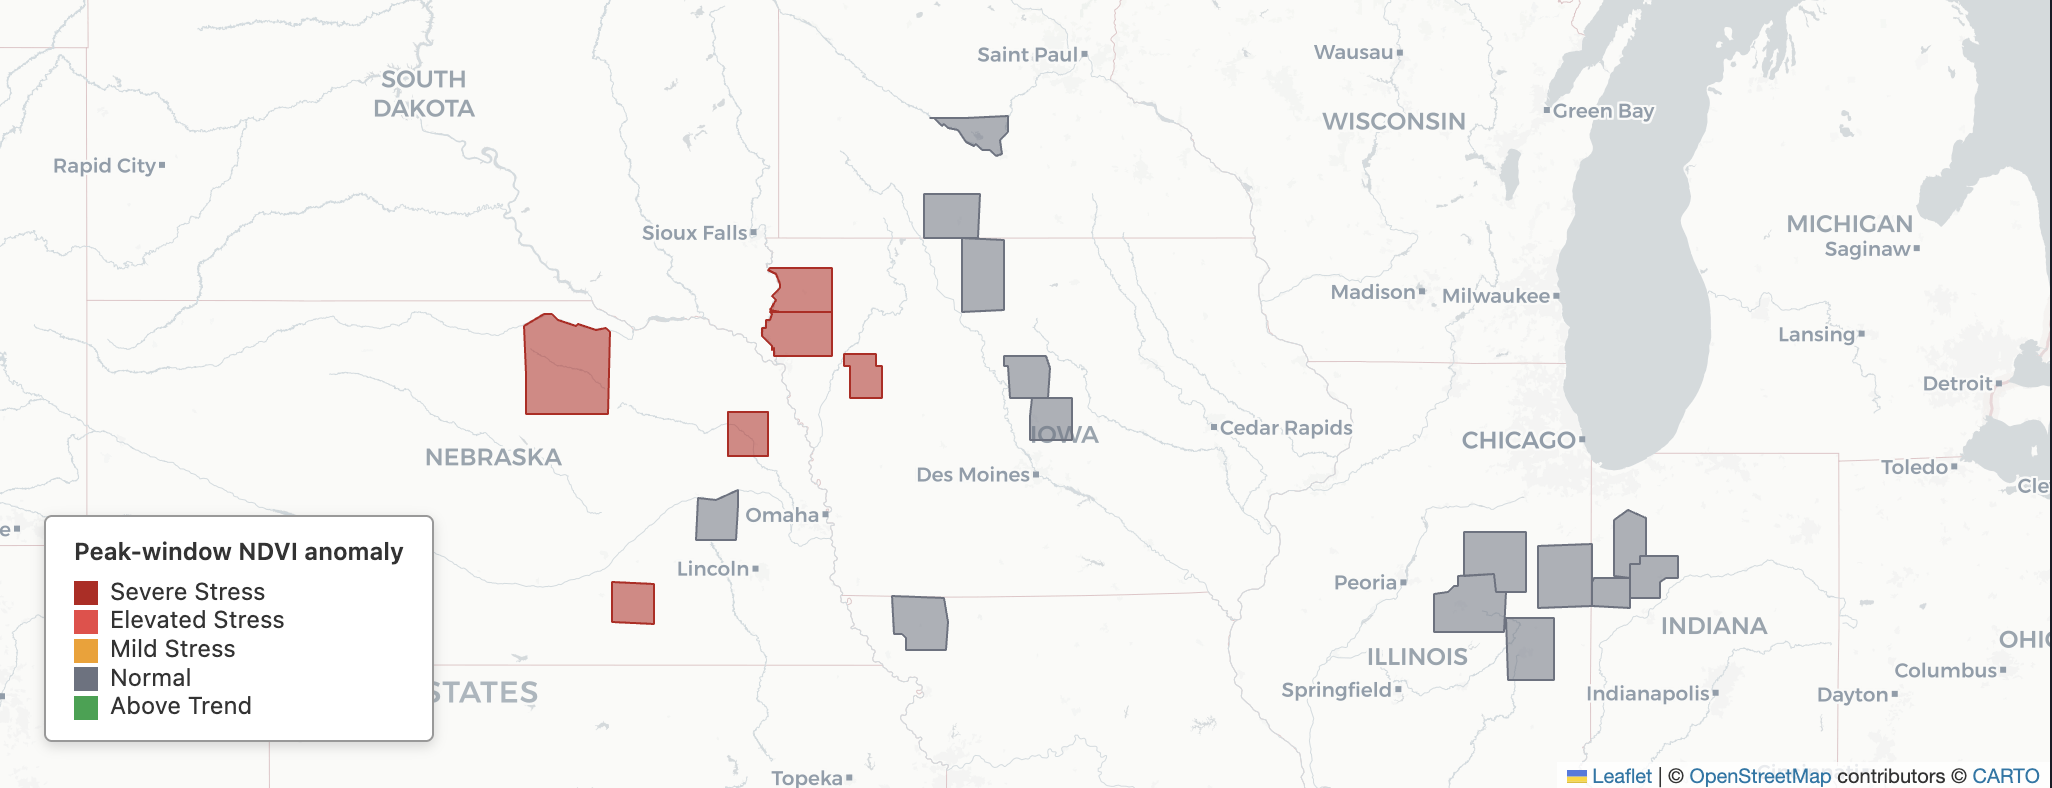

# Corn Stress from Orbit — Research Plumbing

**A commodity-desk stress-monitoring workflow on Wherobots.**

NDVI over the Corn Belt as a yield-risk proxy is an old idea — every major
commodity desk has been running some version of it since ~2012 (Descartes,
Gro, Planet, Orbital Insight, RS Metrics). The edge today isn't "having
NDVI"; it's how fast a research team gets from raw imagery to a typed,
dashboard-ready feed without hand-rolling the plumbing.

This notebook demonstrates that plumbing: STAC ingest over county AOIs,
NDVI map-algebra, zonal stats to a county-week grid, a continuous z-score
stress signal, production-weighted belt aggregation, and a GeoParquet feed
with `bbox` covering for dashboard predicate push-down.

**What this notebook is not.** It is not a production alpha signal. NDVI
is a consequence of weather, not a cause; real desks layer it with GDD,
VPD, precipitation anomaly, and SMAP soil moisture, add EVI / NDWI / SAR
to get past NDVI saturation in the R1–R4 window, run a detrended 10–20
year climatology instead of the 5-year baseline here, and feed the stack
into a weather-conditioned yield model. §10 maps what production layers
on top. The signal-to-position cell in §8 is **not** a backtest — see the
explicit list of what a real backtest would require there.

> **Demo scope.** County AOIs, crop calendar, STAC query, NDVI calculation,
> and GeoParquet export are real. The per-county weekly NDVI series is
> synthesized from a parameterized Gaussian climatology so the notebook
> runs without a live imagery-enabled runtime — the pipeline shape is
> identical under real `RS_MapAlgebra` + `RS_ZonalStats` output.

## The workflow

1. **Define the universe.** 20 top corn-producing counties across IA, IL,
   IN, NE, MN, MO — AOI polygons resolved from Wherobots' `wkls` library.
2. **Tap the imagery.** Sentinel-2 L2A via Wherobots' STAC reader.
   Cloud-filter at the query layer, then per-pixel via the SCL band for
   research-quality ingest.
3. **Compute NDVI.** `(NIR − Red) / (NIR + Red)` per scene via
   `RS_MapAlgebra`, aggregated to a county-week grid with `RS_ZonalStats`.
4. **Score stress.** Continuous z-score of the current-year NDVI anomaly,
   standardized against each county's climatology variance. Suitable for
   combining with other features downstream.
5. **Aggregate to a belt index.** Production-weighted (acres × trend
   yield) weekly index — the single number the desk watches.
6. **Ship the feed.** GeoParquet with `bbox` covering for Iceberg ingest
   and dashboard predicate push-down.

The intentionally-missing piece is **what a desk does with the feed** —
signal combination, yield modeling, sizing, execution. That's where the
quant team's edge lives, and it's outside what a platform demo should claim.

## 1. Setup

Start the SedonaContext to enable Wherobots' data processing.

In [ ]:
from datetime import date, timedelta

from sedona.spark import *
import pyspark.sql.functions as f
from pyspark.sql.types import StructType, StructField, StringType, DoubleType
import wkls
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

config = SedonaContext.builder().getOrCreate()
sedona = SedonaContext.create(config)

## 2. Scenario Parameters & County Universe

Growing-season window, NDVI climatology shape, yield-determining window,
stress-tier thresholds (on the z-score, not the raw anomaly), and the
county list are consolidated in one block. Re-targeting the notebook to
a different crop or region amounts to editing this cell.

**Reuse examples.**

| Scenario | `NDVI_PEAK_WEEK` | `YIELD_WINDOW` | `AOI_COUNTIES` replacement |
|---|---|---|---|
| US corn (default) | 29 (~Jul 20 R1) | 27–33 (R1–R4) | top 20 Corn Belt counties |
| US soybean | 32 (~Aug 10 R3) | 30–36 (R3–R6) | top soy counties (IA/IL/MN) |
| US winter wheat | 22 (~May 30) | 20–26 | top wheat counties (KS/MT/ND) |
| Argentine soy | shift +26 wks (SH) | 4–10 | Pampas provincial departments |

Each county's AOI is the **actual administrative boundary** pulled from
Wherobots' [Well-Known Locations (`wkls`)](https://docs.wherobots.com/latest/develop/wkls)
library — resolved at runtime from `(admin_code, name)`, no hardcoded
coordinates. The slug is `<name>county`; the short form `<name>` matches
a city (`wkls.us.ia.sioux` is Sioux *City*, not the county).

Each county also carries a **trend yield** (bu/acre, approximate 2020–2024
means per USDA NASS). Production weight for the belt index is
`acres × trend_yield` — two counties with equal acres but Iowa vs. Missouri
dryland yields contribute very differently to total supply.

In [ ]:
# ======================================================================
# SCENARIO PARAMETERS — Modify this code block to reuse the notebook for a
# different crop or region. §3 onwards consumes them directly.
# ======================================================================

# --- Crop / market ---
CROP_NAME = "Corn"
CROP_SLUG = CROP_NAME.lower().replace(" ", "_")

# --- Growing season (weeks of year) ---
SEASON_YEAR       = 2025
SEASON_WEEK_START = 14    # ~Apr 1
SEASON_WEEK_END   = 44    # ~Oct 28
WEEKS_OF_YEAR     = np.arange(SEASON_WEEK_START, SEASON_WEEK_END)

# Derive ISO-date strings for the STAC search window
_jan1 = date(SEASON_YEAR, 1, 1)
SEASON_DATE_START = (_jan1 + timedelta(weeks=SEASON_WEEK_START - 1)).isoformat()
SEASON_DATE_END   = (_jan1 + timedelta(weeks=SEASON_WEEK_END   - 1)).isoformat()

# --- NDVI climatology (Gaussian canopy curve) ---
# Production use: 10-20 year detrended climatology per county, not this
# stylized 5-year synthesis. Corn NDVI drifts upward secularly (seed
# genetics, nitrogen management, CO2 fertilization) and a short flat
# baseline systematically mislabels recent healthy years as "above trend".
NDVI_BASELINE       = 0.10   # bare-soil / pre-emergence floor
NDVI_PEAK_AMPLITUDE = 0.70   # peak NDVI above baseline
NDVI_PEAK_WEEK      = 29     # corn R1 silking (~Jul 20)
NDVI_CURVE_WIDTH    = 7.0    # Gaussian σ in weeks

# --- Yield-determining window (where a stress anomaly matters most) ---
YIELD_WINDOW_START = 27      # corn R1
YIELD_WINDOW_END   = 33      # corn R4

# --- Stress-tier thresholds on the peak-window NDVI z-score ---
# Standardizing the anomaly by each county's pre-window noise std makes
# counties comparable and aligns with how downstream models consume the
# signal. Tiers below are for dashboard readability only.
Z_SEVERE   = -3.0
Z_ELEVATED = -1.5
Z_MILD     = -0.5
Z_NORMAL   =  0.5

# --- County universe: (name, admin_code, acres_k, trend_yield_bpa) ---
# Acres planted and trend yield per USDA NASS (approx 2020-2024 means).
# Production weight = acres * trend_yield, not acres alone: yield/acre
# varies materially by state (NE irrigated > MO dryland) and a belt-level
# index that ignores yield misweights which counties actually matter for
# the supply story.
AOI_COUNTIES = [
    ("Sioux",      "IA", 285, 205),
    ("Plymouth",   "IA", 268, 200),
    ("Ida",        "IA", 142, 198),
    ("Kossuth",    "IA", 298, 202),
    ("Hamilton",   "IA", 201, 208),
    ("Story",      "IA", 188, 206),
    ("McLean",     "IL", 321, 215),
    ("Iroquois",   "IL", 258, 210),
    ("Champaign",  "IL", 235, 218),
    ("Livingston", "IL", 241, 212),
    ("Benton",     "IN", 166, 198),
    ("White",      "IN", 153, 195),
    ("Jasper",     "IN", 141, 192),
    ("Holt",       "NE", 224, 192),  # predominantly irrigated
    ("Cuming",     "NE", 182, 198),
    ("Clay",       "NE", 164, 205),
    ("Butler",     "NE", 176, 200),
    ("Nicollet",   "MN", 132, 195),
    ("Martin",     "MN", 148, 198),
    ("Nodaway",    "MO", 138, 168),  # dryland, lower trend
]

# --- Demo-only: inject a synthetic stress anomaly so the signal is visible ---
STRESSED_COUNTIES     = {"Sioux", "Plymouth", "Ida", "Holt", "Cuming", "Clay"}
STRESS_CENTER_WEEK    = 28
STRESS_DURATION_WEEKS = 4.0
STRESS_AMPLITUDE      = -0.18

print(f"Crop:          {CROP_NAME}")
print(f"Season:        week {SEASON_WEEK_START} ({SEASON_DATE_START}) -> "
      f"week {SEASON_WEEK_END} ({SEASON_DATE_END})")
print(f"Yield window:  weeks {YIELD_WINDOW_START}-{YIELD_WINDOW_END}")
print(f"AOI universe:  {len(AOI_COUNTIES)} counties")

In [ ]:
def county_wkt(state: str, county: str) -> str:
    """Resolve (state, county) to its WKT polygon via wkls, Wherobots'
    built-in library that easily fetches administrative boundaries.

    The slug is `<name>county`, not `<name>` — the short form matches a
    city (`wkls.us.ia.sioux` is Sioux *City*), and silently returning the
    wrong geometry is worse than failing loudly."""

    base = county.lower().replace(" ", "").replace(".", "").replace("'", "")
    return getattr(getattr(wkls.us, state.lower()), f"{base}county").wkt()

county_rows = [
    (c, s, float(a), float(y), county_wkt(s, c))
    for c, s, a, y in AOI_COUNTIES
]

county_schema = StructType([
    StructField("county",           StringType()),
    StructField("state",            StringType()),
    StructField("corn_acres_k",     DoubleType()),
    StructField("trend_yield_bpa",  DoubleType()),
    StructField("aoi_wkt",          StringType()),
])

counties_df = (
    sedona.createDataFrame(county_rows, county_schema)
    .withColumn("aoi", f.expr("ST_GeomFromWKT(aoi_wkt)"))
    .withColumn("lon", f.expr("ST_X(ST_Centroid(aoi))"))
    .withColumn("lat", f.expr("ST_Y(ST_Centroid(aoi))"))
    # Production weight = acres (k) × yield (bu/acre) / 1000 → million bu
    .withColumn("prod_weight_mbu",
                f.col("corn_acres_k") * f.col("trend_yield_bpa") / 1000.0)
    .drop("aoi_wkt")
)
counties_df.createOrReplaceTempView("counties")

totals = sedona.sql("""
    SELECT COUNT(*) AS n,
           ROUND(SUM(corn_acres_k)/1000.0, 1)      AS acres_M,
           ROUND(SUM(prod_weight_mbu)/1000.0, 2)   AS production_Bbu
    FROM counties
""").toPandas().iloc[0]

print(f"{CROP_NAME} universe: {int(totals.n)} counties, "
      f"{totals.acres_M:.1f}M acres, {totals.production_Bbu:.2f}Bbu "
      f"trend production — AOIs from wkls")
counties_df.select("county", "state", "corn_acres_k",
                   "trend_yield_bpa", "prod_weight_mbu").show(truncate=False)

## 3. Tap the Imagery — Sentinel-2 over the Corn Belt

Sentinel-2 L2A provides 10 m red/NIR bands on a 5-day nominal revisit. In
practice, cloud cover over the Corn Belt in July — exactly when the
yield-determining window hits — cuts effective per-county clear coverage
to 2–4 scenes per month. Production pipelines supplement with Landsat 8/9,
HLS (harmonized), or Sentinel-1 SAR (all-weather soil-moisture proxy) for
the weeks when optical imagery drops out.

Cloud filtering happens in two places:

- **At query time**, via a `query={"eo:cloud_cover": {"lt": 20}}` predicate
  against STAC item metadata.
- **Per-pixel at read time**, using the Sentinel-2 Scene Classification
  Layer (SCL) band to mask cloud, cloud shadow, and snow before
  `RS_MapAlgebra`.

Below we hit the public Element 84 STAC catalog for one representative
county to show the data supply is real. The NDVI math (§4) is what
`RS_MapAlgebra` runs on each retrieved scene.

In [ ]:
from sedona.stac.client import Client

# Representative AOI for the imagery illustration — first county in the list.
# Take the bbox straight from the wkls polygon so the STAC search covers the
# actual county footprint, not a fixed-radius circle around a centroid.

rep_name, rep_state = AOI_COUNTIES[0][:2]
_bb = sedona.sql(f"""
    SELECT ST_XMin(aoi) AS xmin, ST_YMin(aoi) AS ymin,
           ST_XMax(aoi) AS xmax, ST_YMax(aoi) AS ymax
    FROM counties WHERE county='{rep_name}' AND state='{rep_state}'
""").collect()[0]
rep_bbox = [_bb.xmin, _bb.ymin, _bb.xmax, _bb.ymax]

stac = Client.open("https://earth-search.aws.element84.com/v1")

# The Sedona STAC client wraps endpoint errors in a generic RuntimeError;
# retry across datetime formats before giving up.
items_list = []
for dt_expr in [
    f"{SEASON_DATE_START}T00:00:00Z/{SEASON_DATE_END}T00:00:00Z",
    f"{SEASON_DATE_START}/{SEASON_DATE_END}",
    str(SEASON_YEAR),
]:
    try:
        items = stac.search(
            collection_id="sentinel-2-c1-l2a",
            bbox=rep_bbox,
            datetime=dt_expr,
            max_items=200,
            return_dataframe=False,
        )
        items_list = list(items)
        print(f"STAC search succeeded: datetime={dt_expr!r}")
        break
    except Exception as e:
        print(f"  retry: {dt_expr!r} -> {type(e).__name__}")

if items_list:
    print(f"\nSentinel-2 scenes over {rep_name}, {rep_state}: {len(items_list)}")
    print("\nMost recent scenes:")
    for item in sorted(items_list, key=lambda x: x.datetime, reverse=True)[:5]:
        print(f"  {item.datetime.strftime('%Y-%m-%d')}  {item.id}")
else:
    print("STAC endpoint unavailable — continuing with demo narrative.")
    print("Sentinel-2 nominally revisits the AOI every ~5 days at 10 m, "
          "yielding ~35 cloud-screened scenes per growing season.")

## 4. NDVI in Production — the One-Liner

On each Sentinel-2 scene the production pipeline runs one map-algebra call:

```python
ndvi = RS_MapAlgebra(rast, 'FLOAT32', 'out = (rast[7] - rast[3]) / (rast[7] + rast[3]);')
# rast[3] = B04 (Red), rast[7] = B08 (NIR)
```

followed by `RS_ZonalStats(ndvi, county_aoi, 'mean')` to aggregate to a
per-(county, scene) average. Repeating across the growing-season STAC
result produces the (county, week, NDVI) table §5 operates on.

**NDVI saturation caveat.** NDVI saturates around 0.85 over dense canopy —
exactly the regime corn reaches during R1–R4, the yield-determining weeks
where stress matters most. Inside the peak window, real stress is often
invisible in NDVI alone. Production pipelines compute EVI (enhanced, less
saturated in high biomass), NDWI (moisture, via SWIR bands), and red-edge
indices on the same `RS_MapAlgebra` pass and let downstream models weight
them. This notebook sticks with NDVI for narrative simplicity; swap in
the additional indices for a real research pipeline.

In this demo we fabricate the (county, week, NDVI) table directly from a
parameterized Gaussian climatology plus per-county noise and an optional
stress injection, so the rest of the pipeline exercises real logic on
realistic numbers without requiring a live imagery-enabled runtime.

## 5. County-Week NDVI Series — Current Year vs. Climatology

For each of the 20 counties, generate a 30-week current-year NDVI series
and a climatology baseline. A handful of counties are injected with a
drought-stress anomaly so the signal in §6/§7 has something to react to.

**Climatology caveat.** The 5-year mean baseline is convenient for the
demo but too short and untreated for production use. Corn NDVI drifts
secularly upward from seed genetics, nitrogen management, and CO₂
fertilization; a 10–20 year detrended baseline, ideally with regime
breaks for major cultivar shifts, is what a research team would build.
HLS (Sentinel-2 + Landsat harmonized) plus the MODIS archive back to
2000 is the usual data stack for that climatology.

In [ ]:
# Reference NDVI climatology — Gaussian canopy curve parameterized in §2.
# This is what RS_ZonalStats(NDVI, county_aoi) would produce against a
# healthy season; per-county departures from this shape are the signal.
ref_ndvi = NDVI_BASELINE + NDVI_PEAK_AMPLITUDE * np.exp(
    -((WEEKS_OF_YEAR - NDVI_PEAK_WEEK) / NDVI_CURVE_WIDTH) ** 2
)

rng = np.random.default_rng(7)

rows = []
for county, state, acres_k, _yield in AOI_COUNTIES:
    # Climatology = reference curve + small county-specific bias
    bias = rng.normal(0, 0.015)
    climo = np.clip(ref_ndvi + bias, 0, 0.95)

    # Current-year NDVI: climatology + noise + optional stress dip
    noise = rng.normal(0, 0.012, len(WEEKS_OF_YEAR))
    current = climo + noise
    if county in STRESSED_COUNTIES:
        stress = STRESS_AMPLITUDE * np.exp(
            -((WEEKS_OF_YEAR - STRESS_CENTER_WEEK) / STRESS_DURATION_WEEKS) ** 2
        )
        current = current + stress
    current = np.clip(current, 0, 0.95)

    for w, climo_v, cur_v in zip(WEEKS_OF_YEAR, climo, current):
        rows.append((
            county, state, int(w),
            float(round(climo_v, 4)),
            float(round(cur_v, 4)),
            float(round(cur_v - climo_v, 4)),
            float(acres_k),
        ))

ndvi_schema = StructType([
    StructField("county",        StringType()),
    StructField("state",         StringType()),
    StructField("week",          StringType()),   # keep as string week-of-year
    StructField("ndvi_climo",    DoubleType()),
    StructField("ndvi_current",  DoubleType()),
    StructField("ndvi_anomaly",  DoubleType()),
    StructField("corn_acres_k",  DoubleType()),
])

ndvi_df = sedona.createDataFrame(
    [(c, s, str(w), cl, cu, an, ac) for c, s, w, cl, cu, an, ac in rows],
    ndvi_schema
)
ndvi_df.createOrReplaceTempView("county_ndvi")
print(f"County-week NDVI observations: {ndvi_df.count():,}")

# Quick visual — stressed counties pull away from climatology during the peak
pdf = ndvi_df.toPandas()
pdf["week"] = pdf["week"].astype(int)

fig, ax = plt.subplots(figsize=(11, 4.5))
for c in pdf["county"].unique():
    sub = pdf[pdf["county"] == c].sort_values("week")
    is_stressed = c in STRESSED_COUNTIES
    ax.plot(sub["week"], sub["ndvi_current"],
            color="#E24B4A" if is_stressed else "#888780",
            lw=1.8 if is_stressed else 0.9,
            alpha=0.95 if is_stressed else 0.5,
            label=c if is_stressed else None)
ax.plot(WEEKS_OF_YEAR, ref_ndvi, color="#2d7a2d", lw=2.5, ls="--",
        label="Healthy climatology")
ax.axvspan(YIELD_WINDOW_START, YIELD_WINDOW_END, alpha=0.08, color="#EF9F27")
ax.set_xlabel("Week of year")
ax.set_ylabel("NDVI")
ax.set_title(f"Current-season {CROP_NAME} NDVI per county — stressed counties in red",
             fontsize=12, pad=8)
ax.legend(loc="lower center", ncol=4, fontsize=8)
ax.set_ylim(0, 0.95)
plt.tight_layout()
plt.savefig(f"{CROP_SLUG}_ndvi_county_series.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Stress Detection — Peak-Window Z-Score by County

The actionable number is the current-year NDVI deviation during the
yield-determining window (weeks 27–33), **standardized** against each
county's own week-to-week anomaly volatility. A raw anomaly of −0.05 in a
stable county and −0.05 in a volatile county mean very different things;
dividing by the county's pre-window anomaly std puts them on the same
scale and makes the output a feature a downstream model can consume
directly.

The tier labels below are only for dashboard readability — any real model
operates on the continuous `peak_zscore` column.

In [ ]:
stress_df = sedona.sql(f"""
    WITH county_stats AS (
      SELECT
        c.county, c.state, c.corn_acres_k, c.trend_yield_bpa,
        AVG(CASE WHEN CAST(n.week AS INT) BETWEEN {YIELD_WINDOW_START}
                                              AND {YIELD_WINDOW_END}
                 THEN n.ndvi_current END) AS avg_peak_ndvi,
        AVG(CASE WHEN CAST(n.week AS INT) BETWEEN {YIELD_WINDOW_START}
                                              AND {YIELD_WINDOW_END}
                 THEN n.ndvi_climo END)   AS avg_peak_climo,
        AVG(CASE WHEN CAST(n.week AS INT) BETWEEN {YIELD_WINDOW_START}
                                              AND {YIELD_WINDOW_END}
                 THEN n.ndvi_anomaly END) AS peak_anomaly,
        STDDEV(CASE WHEN CAST(n.week AS INT) < {YIELD_WINDOW_START}
                    THEN n.ndvi_anomaly END) AS prewindow_anomaly_std
      FROM county_ndvi n
      JOIN counties c USING (county, state)
      GROUP BY c.county, c.state, c.corn_acres_k, c.trend_yield_bpa
    )
    SELECT
      county, state, corn_acres_k, trend_yield_bpa,
      ROUND(avg_peak_ndvi, 3)         AS avg_peak_ndvi,
      ROUND(avg_peak_climo, 3)        AS avg_peak_climo,
      ROUND(peak_anomaly, 3)          AS peak_anomaly,
      ROUND(prewindow_anomaly_std, 4) AS prewindow_std,
      ROUND(peak_anomaly / NULLIF(prewindow_anomaly_std, 0), 2) AS peak_zscore,
      CASE
        WHEN peak_anomaly / NULLIF(prewindow_anomaly_std, 0) <= {Z_SEVERE}   THEN 'Severe Stress'
        WHEN peak_anomaly / NULLIF(prewindow_anomaly_std, 0) <= {Z_ELEVATED} THEN 'Elevated Stress'
        WHEN peak_anomaly / NULLIF(prewindow_anomaly_std, 0) <= {Z_MILD}     THEN 'Mild Stress'
        WHEN peak_anomaly / NULLIF(prewindow_anomaly_std, 0) <  {Z_NORMAL}   THEN 'Normal'
        ELSE                                                                     'Above Trend'
      END AS stress_tier
    FROM county_stats
    ORDER BY peak_zscore ASC
""").cache()
stress_df.createOrReplaceTempView("county_stress")
stress_df.select("county", "state", "peak_anomaly",
                 "prewindow_std", "peak_zscore", "stress_tier").show(truncate=False)

## 7. Belt-Level Index — Production-Weighted Weekly Signal

Aggregate county-level anomalies into a single belt-wide index weighted
by **production** (acres × trend yield), not acres alone. A 285-kilo-acre
county in Iowa producing 205 bu/acre contributes more to Corn Belt supply
than a 285-kilo-acre county in Missouri at 168 bu/acre; a belt index that
ignores the yield dimension misweights which counties drive the supply
story.

The chart plots the belt z-score — the weekly production-weighted
anomaly, standardized against the pre-window noise of the same series.
Values below −1 σ are the "something to look at" threshold; below −2 σ
is where a desk would start reshaping risk.

**Not shown.** Prior versions of this notebook plotted a "satellite leads
USDA by 3 weeks" chart built by `.shift(3)` on synthesized data — it was
tautological, not evidence. The empirical lead-lag (satellite NDVI
anomalies preceding Crop Progress condition ratings) is well-documented
in the literature but verifying it needs multi-year data and a proper
event study, both outside this demo's scope.

In [ ]:
weekly_index_df = sedona.sql(f"""
    SELECT
        CAST(n.week AS INT) AS week,
        ROUND(SUM(n.ndvi_anomaly * c.corn_acres_k * c.trend_yield_bpa)
              / SUM(c.corn_acres_k * c.trend_yield_bpa), 4)
            AS weighted_anomaly,
        ROUND(STDDEV(n.ndvi_anomaly), 4) AS cross_county_std
    FROM county_ndvi n
    JOIN counties c USING (county, state)
    GROUP BY CAST(n.week AS INT)
    ORDER BY week
""").toPandas()

wi = weekly_index_df.sort_values("week").copy()

# Standardize the belt-level weekly anomaly against its own pre-window
# std — "z = -1.5" means the belt is 1.5σ below its off-season noise.
prewindow_std = wi.loc[wi["week"] < YIELD_WINDOW_START, "weighted_anomaly"].std()
wi["belt_zscore"] = wi["weighted_anomaly"] / prewindow_std

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(wi["week"], wi["belt_zscore"],
        color="#1f77b4", lw=2.2,
        label="Belt z-score (production-weighted NDVI anomaly)")
ax.fill_between(wi["week"], -1, 1, alpha=0.06, color="#1f77b4",
                label="±1σ (normal range)")
ax.axhline(0, color="#333", lw=0.5)
ax.axhline(-2, color="#E24B4A", lw=0.8, ls=":", alpha=0.7,
           label="−2σ (risk-reshaping threshold)")
ax.axvspan(YIELD_WINDOW_START, YIELD_WINDOW_END, alpha=0.08, color="#EF9F27",
           label="Yield-determining window")
ax.set_xlabel("Week of year")
ax.set_ylabel("Belt z-score")
ax.set_title(f"{CROP_NAME} belt stress — production-weighted weekly z-score",
             fontsize=12, pad=8)
ax.legend(loc="lower left", fontsize=9)
plt.tight_layout()
plt.savefig(f"{CROP_SLUG}_belt_zscore.png", dpi=150, bbox_inches="tight")
plt.show()

yw_mask = wi["week"].between(YIELD_WINDOW_START, YIELD_WINDOW_END)
print(f"Peak negative belt z-score in yield window: "
      f"{wi.loc[yw_mask, 'belt_zscore'].min():.2f}")
print(f"Weeks in yield window with z < -1.5: "
      f"{(yw_mask & (wi['belt_zscore'] < -1.5)).sum()} of {yw_mask.sum()}")

## 8. Signal-to-Position Pipeline — Illustrative Only

If a desk uses the belt z-score as an overlay on a corn futures book,
something in the stack mechanically maps signal to position. This
section shows that translation pattern for completeness. **It is not a
backtest and is not evidence of alpha.**

What a real backtest requires, none of which is here:

- Multiple growing seasons (this demo has one synthesized year).
- Actual futures prices with **roll adjustments** across the CZ/CH/CK/CN/CU
  contract chain — `pct_change().cumprod()` on a single front-month
  series materially misstates realized return once roll yield is priced
  in.
- Transaction costs and slippage (round-trip ~1–2 bps on CBOT corn).
- Out-of-sample validation and a multiple-testing correction for any
  threshold tuning.
- A benchmark that accounts for futures roll — BCOM Agriculture
  sub-index, SocGen CTA, or an explicit trend-following model, not
  buy-and-hold front-month.
- Sharpe, max drawdown, information ratio, hit rate, HAC-adjusted
  t-stat, bootstrap CIs, turnover.
- An execution latency model: a weekly-rebalanced strategy tagged to
  Monday's Crop Progress release gets a few hours to run ingest →
  zonal-stat → signal update → trade. In practice daily rebuilds on
  every imagery drop are the norm, not weekly.

The cell below shows only the signal → position-sizing step as a
continuous function of the belt z-score. PnL is left to whoever plugs
this into a real price tape.

In [ ]:
# Continuous position sizing from the belt z-score.
# Convention: belt z < 0 means below-climatology vegetation → supply risk →
# long corn. |position| is capped at 1.0 and scales linearly inside ±2σ;
# beyond that the signal is already extreme and further sizing is
# discretionary (model exit, layered hedges, etc.).
POSITION_CAP = 1.0
Z_SCALE      = 2.0

pos = wi.copy()
pos["position"] = (-pos["belt_zscore"] / Z_SCALE).clip(-POSITION_CAP, POSITION_CAP)

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(11, 6), sharex=True, gridspec_kw={"height_ratios": [1, 1]},
)

ax1.plot(pos["week"], pos["belt_zscore"], color="#1f77b4", lw=2.0,
         label="Belt z-score")
ax1.fill_between(pos["week"], -1, 1, alpha=0.06, color="#1f77b4")
ax1.axhline(0, color="#333", lw=0.5)
ax1.axvspan(YIELD_WINDOW_START, YIELD_WINDOW_END, alpha=0.08, color="#EF9F27")
ax1.set_ylabel("Belt z-score")
ax1.legend(loc="lower left", fontsize=9)

ax2.plot(pos["week"], pos["position"], color="#E24B4A", lw=2.0,
         label="Suggested long-corn position (−1…+1)")
ax2.axhline(0, color="#333", lw=0.5)
ax2.axvspan(YIELD_WINDOW_START, YIELD_WINDOW_END, alpha=0.08, color="#EF9F27")
ax2.set_xlabel("Week of year")
ax2.set_ylabel("Position")
ax2.legend(loc="upper left", fontsize=9)

plt.suptitle("Signal → position mapping (illustrative — no PnL)",
             fontsize=12, y=0.995)
plt.tight_layout()
plt.savefig(f"{CROP_SLUG}_signal_to_position.png",
            dpi=150, bbox_inches="tight")
plt.show()

print(f"Weeks with position > 0.5: "
      f"{(pos['position'] > 0.5).sum()} of {len(pos)}")
print(f"Peak position: {pos['position'].max():.2f} at week "
      f"{int(pos.loc[pos['position'].idxmax(), 'week'])}")

## 9. Ship It — GeoParquet Feed for the Desk Dashboard

Export the county-level stress leaderboard as **GeoParquet**: county AOI
polygon as a typed geometry column, plus z-score, tier, raw anomaly,
acres, trend yield, and centroid lat/lon as first-class columns the
dashboard filters on directly. GeoParquet beats GeoJSON here because
columnar scan pulls just the fields rendered, spatial predicates push
down via the `bbox` covering, and Iceberg ingests the file as-is with
no conversion.

In [ ]:
stress_parquet_df = sedona.sql("""
    SELECT
        s.county, s.state,
        s.corn_acres_k, s.trend_yield_bpa,
        s.avg_peak_ndvi, s.peak_anomaly, s.peak_zscore, s.stress_tier,
        c.lon, c.lat,
        c.aoi AS geometry,
        struct(
            ST_XMin(c.aoi) AS xmin, ST_YMin(c.aoi) AS ymin,
            ST_XMax(c.aoi) AS xmax, ST_YMax(c.aoi) AS ymax
        ) AS bbox
    FROM county_stress s
    JOIN counties c USING (county, state)
    ORDER BY s.peak_zscore ASC
""")

out_path = f"/tmp/{CROP_SLUG}_belt_stress.parquet"

# coalesce(1) keeps it to a single part file since we only have ~20 counties.
# The `bbox` struct column (populated above from ST_XMin/YMin/XMax/YMax of
# the geometry) is what `geoparquet.covering` references — downstream
# readers use it to push spatial predicates down without decoding the full
# polygon.
stress_parquet_df.coalesce(1) \
    .write.format("geoparquet") \
    .option("geoparquet.version", "1.1.0") \
    .option("geoparquet.covering", "bbox") \
    .mode("overwrite") \
    .save(out_path)

print(f"Wrote {stress_parquet_df.count()} county stress features to {out_path}/\n")
stress_parquet_df.select("county", "state", "peak_zscore",
                         "stress_tier", "trend_yield_bpa") \
                 .show(5, truncate=False)

## 10. Preview on a Map

In [ ]:
import folium
import json

map_pdf = sedona.sql("""
    SELECT
        s.county, s.state, s.corn_acres_k, s.trend_yield_bpa,
        s.peak_anomaly, s.peak_zscore, s.stress_tier,
        ST_AsGeoJSON(c.aoi) AS geojson
    FROM county_stress s
    JOIN counties c USING (county, state)
""").toPandas()

tier_color = {
    "Severe Stress":   "#b91c1c",
    "Elevated Stress": "#ef4444",
    "Mild Stress":     "#f59e0b",
    "Normal":          "#6b7280",
    "Above Trend":     "#16a34a",
}

fmap = folium.Map(location=[41.5, -93.5], zoom_start=5, tiles="CartoDB positron")

for _, row in map_pdf.iterrows():
    color = tier_color.get(row["stress_tier"], "#6b7280")
    folium.GeoJson(
        json.loads(row["geojson"]),
        style_function=lambda _x, color=color: {
            "fillColor": color, "color": color, "weight": 1, "fillOpacity": 0.55,
        },
        tooltip=folium.Tooltip(
            f"<b>{row['county']}, {row['state']}</b><br>"
            f"Tier: {row['stress_tier']}<br>"
            f"Peak z-score: {row['peak_zscore']:+.2f}<br>"
            f"Peak anomaly: {row['peak_anomaly']:+.3f}<br>"
            f"{row['corn_acres_k']:,.0f}k acres × "
            f"{row['trend_yield_bpa']:.0f} bu/ac trend",
        ),
    ).add_to(fmap)

legend_html = """
<div style="position: fixed; bottom: 24px; left: 24px; z-index: 9999;
            background: white; padding: 10px 14px; border: 1px solid #999;
            border-radius: 4px; font: 12px system-ui, sans-serif;
            box-shadow: 0 2px 6px rgba(0,0,0,0.15);">
  <div style="font-weight:600; margin-bottom:6px;">Peak-window NDVI z-score</div>
  <div><span style="display:inline-block;width:12px;height:12px;background:#b91c1c;margin-right:6px;vertical-align:middle"></span>Severe Stress (z ≤ -3)</div>
  <div><span style="display:inline-block;width:12px;height:12px;background:#ef4444;margin-right:6px;vertical-align:middle"></span>Elevated Stress (z ≤ -1.5)</div>
  <div><span style="display:inline-block;width:12px;height:12px;background:#f59e0b;margin-right:6px;vertical-align:middle"></span>Mild Stress (z ≤ -0.5)</div>
  <div><span style="display:inline-block;width:12px;height:12px;background:#6b7280;margin-right:6px;vertical-align:middle"></span>Normal</div>
  <div><span style="display:inline-block;width:12px;height:12px;background:#16a34a;margin-right:6px;vertical-align:middle"></span>Above Trend</div>
</div>
"""
fmap.get_root().html.add_child(folium.Element(legend_html))

fmap

---

## 10. From demo to production

What changes between this notebook and a production signal — the
checklist a desk would run before trusting the feed for sizing.

### Data sources (swap synthesized → live)

| Demo | Production |
|---|---|
| 20 counties, static list | NASS Quick Stats top-N by planted acres, refreshed pre-season |
| County AOI via `wkls` | Same, plus NASS Cropland Data Layer mask for corn pixels only |
| Synthesized NDVI curve | `RS_MapAlgebra((B08-B04)/(B08+B04))` + `RS_ZonalStats` on cloud-screened Sentinel-2 L2A |
| 5-year flat climatology | 15-year detrended per-county climatology (HLS + MODIS for pre-2015), regime-broken for cultivar generations |
| Acreage × trend yield weighting | Same, but refreshed pre-season from NASS Quick Stats |

### Signal quality (what makes NDVI defensible)

| Demo | Production |
|---|---|
| NDVI only | NDVI + EVI + NDWI + red-edge (get past saturation in R1–R4) |
| Optical only | + Sentinel-1 SAR soil-moisture proxy for cloudy weeks |
| No weather covariates | + ERA5 GDD/VPD/precip anomaly, SMAP root-zone moisture, NOAA US Drought Monitor |
| Signal = raw z-score | Signal = residual of yield regression on {weather, satellite, Crop Progress priors} |

### Output, scheduling, execution

| Demo | Production |
|---|---|
| `/tmp/*.parquet` | S3 → Iceberg table; dashboard reads via Wherobots SQL endpoint |
| Weekly rebuild in-notebook | Daily rebuild on new imagery; hourly on USDA release days |
| Single manual run | Scheduled job (Airflow / Wherobots native triggers) with an SLA on feed freshness |
| No alerting | Slack / email on \|z\| crossing threshold or >2σ week-over-week change |

### What this demo deliberately does not do

- **No trading PnL.** Coupling a signal to PnL requires roll-adjusted
  futures (CBOT CZ/CH/CK/CN/CU chain), transaction costs, a risk model,
  sizing, and execution — all outside the platform's scope. §8 shows the
  signal → position step only, not the price tape or PnL.
- **No lead-lag claim vs. USDA reports.** The empirical literature
  documents satellite stress preceding Crop Progress condition ratings by
  ~2–4 weeks (cf. Johnson 2014 and subsequent work), but verifying that
  requires multi-year data and a proper event study; claiming it off
  one-year synthesized data would be fiction.
- **No multiple-testing correction on tier thresholds.** Tiers exist for
  dashboard readability only; a model consumes the continuous
  `peak_zscore` directly.

### Outputs this notebook produces

| File | Contents |
|---|---|
| `{CROP_SLUG}_ndvi_county_series.png` | Per-county NDVI, stressed counties highlighted |
| `{CROP_SLUG}_belt_zscore.png` | Belt-level production-weighted z-score time series |
| `{CROP_SLUG}_signal_to_position.png` | Belt z-score → illustrative position mapping (no PnL) |
| `/tmp/{CROP_SLUG}_belt_stress.parquet/` | GeoParquet: county AOIs + z-score + tier + trend yield, `bbox`-covered for predicate push-down |